In [ ]:
import cv2
import sys
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
from google.colab.patches import cv2_imshow

In [ ]:
VIDEO_PATH         = '/content/TrafficVideo.mp4'
OUTPUT_VIDEO_PATH  = 'output_tracked.mp4'
RESIZE_TO          = (640, 360)
FPS_ASSUMED        = 30

In [ ]:

MOG_HISTORY        = 200    # Frames to remember background
MOG_VAR_THRESHOLD  = 16     # Sensitivity to pixel changes
MIN_CONTOUR_AREA   = 200    # Minimum pixel area for a valid vehicle blob
IGNORE_TOP_FRAC    = 0.15   # Ignore top 15% of frame (sky/buildings)

# Counting Parameters
COUNT_LINE_FRAC    = 0.25  # ACCURACY FIX: Line at 25% height (closer to camera)
WARMUP_FRAMES      = 200    # Frames to skip while MOG2 initializes

# Tracker Parameters
MAX_MATCH_DIST     = 80     # Max pixel distance to match a moving centroid
MAX_TRACK_AGE      = 10     # Frames a track can stay alive without detection
MIN_TRACK_HITS     = 5      # ACCURACY FIX: Track must be seen 5 times to count


In [ ]:
class CentroidTracker:
    def __init__(self, max_dist=80, max_age=10, min_hits=5):
        self.next_id      = 0
        self.tracks       = {}   # {id: {'cx': int, 'cy': int, 'age': int, 'hits': int}}
        self.crossed_ids  = set()
        self.max_dist     = max_dist
        self.max_age      = max_age
        self.min_hits     = min_hits
        self.count_up     = 0
        self.count_down   = 0

    def update(self, centroids, line_y):
        """Updates tracks and detects valid line crossings."""
        # 1. Age all existing tracks
        for tid in list(self.tracks.keys()):
            self.tracks[tid]['age'] += 1
            if self.tracks[tid]['age'] > self.max_age:
                del self.tracks[tid]

        matched_track_ids = set()
        matched_cent_idxs = set()

        # 2. Match current centroids to existing tracks (Greedy Nearest-Neighbour)
        for ci, (cx, cy) in enumerate(centroids):
            best_dist = self.max_dist
            best_tid  = -1

            for tid, tr in self.tracks.items():
                if tid in matched_track_ids:
                    continue
                d = np.hypot(cx - tr['cx'], cy - tr['cy'])
                if d < best_dist:
                    best_dist = d
                    best_tid  = tid

            if best_tid >= 0:
                # Update matched track coordinates, reset age, and increment hits
                prev_cy = self.tracks[best_tid]['cy']
                self.tracks[best_tid]['hits'] += 1
                self.tracks[best_tid].update({'cx': cx, 'cy': cy, 'age': 0})
                matched_track_ids.add(best_tid)
                matched_cent_idxs.add(ci)

                # 3. Crossing Detection (Requires track to be "mature")
                is_uncrossed = best_tid not in self.crossed_ids
                is_mature    = self.tracks[best_tid]['hits'] >= self.min_hits

                if is_uncrossed and is_mature:
                    # Check if Cy flipped across the virtual line
                    if (prev_cy < line_y <= cy) or (prev_cy > line_y >= cy):
                        self.crossed_ids.add(best_tid)

                        # Determine direction
                        if cy > prev_cy:   # Moving downward
                            self.count_down += 1
                        else:              # Moving upward
                            self.count_up += 1

        # 4. Spawn new tracks for unmatched centroids
        for ci, (cx, cy) in enumerate(centroids):
            if ci not in matched_cent_idxs:
                self.tracks[self.next_id] = {'cx': cx, 'cy': cy, 'age': 0, 'hits': 1}
                self.next_id += 1

    def draw(self, frame):
        """Renders track IDs and dots onto the current frame."""
        for tid, tr in self.tracks.items():
            # Fade out young tracks visually, bold mature tracks
            if tr['hits'] < self.min_hits:
                colour = (100, 100, 100) # Gray for immature/untrusted tracks
            else:
                colour = (
                    int((tid * 73) % 255),
                    int((tid * 137) % 255),
                    int((tid * 211) % 255),
                )
            cv2.circle(frame, (tr['cx'], tr['cy']), 6, colour, -1)
            cv2.putText(frame, str(tid), (tr['cx'] + 8, tr['cy'] - 4),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.45, colour, 1)


In [ ]:
mog = cv2.createBackgroundSubtractorMOG2(
    history=MOG_HISTORY,
    varThreshold=MOG_VAR_THRESHOLD,
    detectShadows=True
)

In [ ]:
kernel_open  = cv2.getStructuringElement(cv2.MORPH_RECT, (5,  5))   # Cleans static noise
kernel_close = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))  # Glues fragmented cars

def clean_mask(mask, ignore_height):
    """Applies ROI cropping, thresholding, and morphological operations."""
    # ROI: Black out top portion to prevent processing sky/background
    mask[0:ignore_height, :] = 0

    # Noise reduction pipeline
    mask = cv2.medianBlur(mask, 5)
    _, mask = cv2.threshold(mask, 200, 255, cv2.THRESH_BINARY) # Suppress shadows
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  kernel_open)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel_close)
    return mask

--- Traffic Monitoring Pipeline Started ---
Source   : /content/TrafficVideo.mp4
Output   : output_tracked.mp4
Warming up MOG2 for 200 frames...
NOTE: Live preview disabled for maximum Colab processing speed.

Processed 100 frames... (Current Count: 0)
Processed 200 frames... (Current Count: 0)
Processed 300 frames... (Current Count: 1)
Processed 400 frames... (Current Count: 4)
Processed 500 frames... (Current Count: 7)
Processed 600 frames... (Current Count: 12)
Processed 700 frames... (Current Count: 13)
Processed 800 frames... (Current Count: 18)
Processed 900 frames... (Current Count: 21)
Processed 1000 frames... (Current Count: 24)
Processed 1100 frames... (Current Count: 28)

  TRAFFIC MONITORING — FINAL SUMMARY
  Frames processed    : 1192
  Warmup frames       : 200  (excluded from count)
  Vehicles going UP   : 25
  Vehicles going DOWN : 8
  Total vehicles      : 33
  Unique tracks seen  : 72
  Video Saved To      : output_tracked.mp4


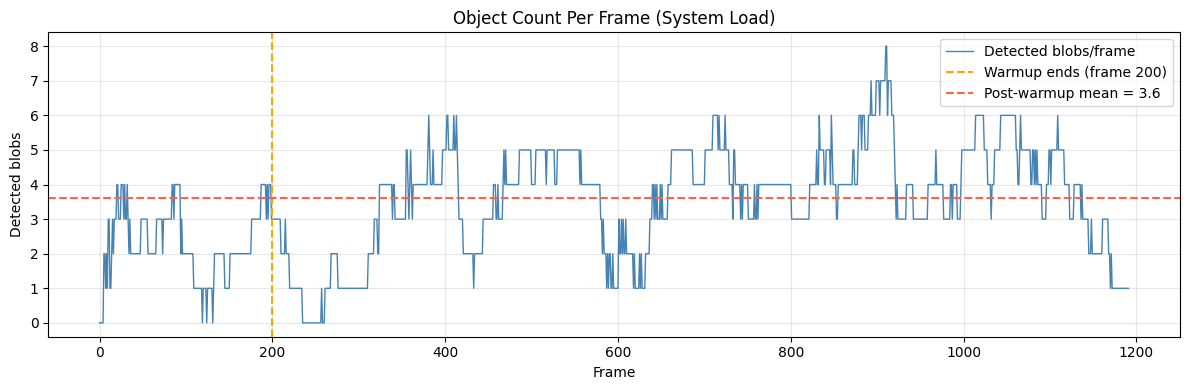

Saved analytics plot → traffic_analytics.png


In [ ]:
if __name__ == "__main__":

    cap = cv2.VideoCapture(VIDEO_PATH)
    if not cap.isOpened():
        print(f"ERROR: Cannot open {VIDEO_PATH}. Check file path.")
        sys.exit()

    W, H     = RESIZE_TO
    line_y   = int(H * COUNT_LINE_FRAC)
    ignore_h = int(H * IGNORE_TOP_FRAC)

    tracker  = CentroidTracker(max_dist=MAX_MATCH_DIST,
                               max_age=MAX_TRACK_AGE,
                               min_hits=MIN_TRACK_HITS)

    # Initialize Video Writer (MP4 output)
    FOURCC = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(OUTPUT_VIDEO_PATH, FOURCC, FPS_ASSUMED, RESIZE_TO)

    if not out.isOpened():
        print(f"ERROR: Could not open video writer for {OUTPUT_VIDEO_PATH}")
        sys.exit()

    # Data collection for analytics
    obj_count_history = deque(maxlen=9000)
    frame_count       = 0

    print(f"--- Traffic Monitoring Pipeline Started ---")
    print(f"Source   : {VIDEO_PATH}")
    print(f"Output   : {OUTPUT_VIDEO_PATH}")
    print(f"Warming up MOG2 for {WARMUP_FRAMES} frames...")
    print(f"NOTE: Live preview disabled for maximum Colab processing speed.\n")

    # ── FRAME PROCESSING LOOP ──
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        frame_count += 1
        frame = cv2.resize(frame, (W, H))

        # 1. OPTIMIZATION: Convert to grayscale for faster background subtraction
        gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # 2. Background Subtraction & Mask Cleaning (with ROI cutout)
        raw_mask = mog.apply(gray_frame)
        mask     = clean_mask(raw_mask, ignore_h)

        # 3. Detect Blobs (Contours)
        cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        centroids     = []
        current_boxes = []

        for cnt in cnts:
            area = cv2.contourArea(cnt)
            if area < MIN_CONTOUR_AREA:
                continue
            x, y, bw, bh = cv2.boundingRect(cnt)
            cx = x + bw // 2
            cy = y + bh // 2
            centroids.append((cx, cy))
            current_boxes.append((x, y, bw, bh))

        obj_count_history.append(len(centroids))

        # 4. Update tracker & count crossings (Exclude Warmup frames)
        if frame_count > WARMUP_FRAMES:
            tracker.update(centroids, line_y)

        # 5. Visual Annotations
        for (x, y, bw, bh) in current_boxes:
            cv2.rectangle(frame, (x, y), (x+bw, y+bh), (0, 220, 0), 2)

        tracker.draw(frame)

        # Draw Counting Line
        cv2.line(frame, (0, line_y), (W, line_y), (0, 0, 255), 2)

        # Draw ROI Line (visual cue of where processing starts)
        cv2.line(frame, (0, ignore_h), (W, ignore_h), (0, 100, 100), 1)
        cv2.putText(frame, "IGNORED REGION", (10, ignore_h - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 100, 100), 1)

        # Status Overlay
        if frame_count <= WARMUP_FRAMES:
            pct = int(frame_count / WARMUP_FRAMES * 100)
            cv2.rectangle(frame, (10, 10), (10 + pct * 2, 30), (255, 200, 0), -1)
            cv2.putText(frame, f'Warming up MOG2... {pct}%',
                        (12, 26), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,0), 2)
        else:
            cv2.putText(frame, f"UP     : {tracker.count_up}",
                        (10, 35), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)
            cv2.putText(frame, f"DOWN   : {tracker.count_down}",
                        (10, 65), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 255), 2)
            cv2.putText(frame, f"Total  : {tracker.count_up + tracker.count_down}",
                        (10, 95), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 255, 0), 2)
            cv2.putText(frame, f"Active Tracks: {len(tracker.tracks)}",
                        (10, 125), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (200, 200, 200), 1)

        cv2.putText(frame, f'Frame: {frame_count}',
                    (W - 140, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (180,180,180), 1)

        # 6. Output Generation
        out.write(frame)

        # Print progress to Colab console every 100 frames
        if frame_count % 100 == 0:
            print(f"Processed {frame_count} frames... (Current Count: {tracker.count_up + tracker.count_down})")

        # NOTE: cv2_imshow is intentionally commented out for speed.
        # cv2_imshow(frame)

    # Cleanup sequence
    out.release()
    cap.release()
    cv2.destroyAllWindows()

    # ─────────────────────────────────────────────────────────────────────────────
    #  Summary & Analytics
    # ─────────────────────────────────────────────────────────────────────────────
    print('\n' + '='*55)
    print('  TRAFFIC MONITORING — FINAL SUMMARY')
    print('='*55)
    print(f'  Frames processed    : {frame_count}')
    print(f'  Warmup frames       : {WARMUP_FRAMES}  (excluded from count)')
    print(f'  Vehicles going UP   : {tracker.count_up}')
    print(f'  Vehicles going DOWN : {tracker.count_down}')
    print(f'  Total vehicles      : {tracker.count_up + tracker.count_down}')
    print(f'  Unique tracks seen  : {tracker.next_id}')
    print(f'  Video Saved To      : {OUTPUT_VIDEO_PATH}')
    print('='*55)

    # Plot object count over time
    if obj_count_history:
        counts = list(obj_count_history)
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(counts, color='steelblue', lw=1, label='Detected blobs/frame')
        ax.axvline(WARMUP_FRAMES, color='orange', linestyle='--',
                   label=f'Warmup ends (frame {WARMUP_FRAMES})')
        ax.axhline(np.mean(counts[WARMUP_FRAMES:]), color='tomato', linestyle='--',
                   label=f'Post-warmup mean = {np.mean(counts[WARMUP_FRAMES:]):.1f}')
        ax.set(xlabel='Frame', ylabel='Detected blobs', title='Object Count Per Frame (System Load)')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('traffic_analytics.png', dpi=120)
        plt.show()
        print('Saved analytics plot → traffic_analytics.png')